 # Laboratorio 03 — Intuición estadística

Mario César Barrera Salas - C.C 1003290195

In [1]:
# ============================================================
# PASO 0 — Imports y configuración general
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV,
    validation_curve, learning_curve
)
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


 ## Paso 1 — Recuperar / definir el modelo de la sesión 3
 El hiperparámetro a variar es `gamma`, propio del kernel RBF en SVC.

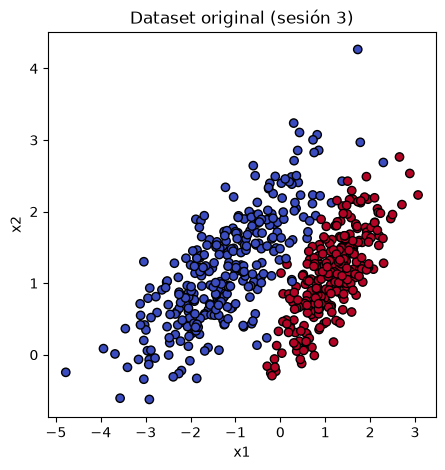

In [ ]:
X, y = make_classification(
    n_samples=600, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, class_sep=1.2,
    random_state=RANDOM_STATE
)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", cmap="coolwarm")
plt.title("Dataset original")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()


 ## Paso 2 — Separar el test
 `X_test` no se vuelve a tocar hasta la evaluación final (Paso 8).
 Esto evita *data leakage*: si el test participa en decidir `gamma`, deja de ser una medida honesta de generalización.

In [3]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Train+val: {len(X_trainval)} ejemplos ({len(X_trainval)/len(X):.0%})")
print(f"Test:      {len(X_test)} ejemplos ({len(X_test)/len(X):.0%})")


Train+val: 480 ejemplos (80%)
Test:      120 ejemplos (20%)


 ## Paso 3 — Definir entrenamiento + validación (80% restante)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) # Se usa K-fold cross-validation sobre el 80% en vez de un único split fijo

pipe = Pipeline([
    ("scaler", StandardScaler()), #evita leakage en el preprocesamiento
    ("svc", SVC(kernel="rbf"))
])


 ## Actividad 1 — Curva de score en función de gamma



 - Eje X en escala logarítmica (gamma se explora en varios órdenes de magnitud).

 - gamma pequeño → fronteras suaves → posible *underfitting*.

 - gamma grande → fronteras muy locales → posible *overfitting*.

 - El mejor gamma es el que maximiza el score de **validación**, no el de train.

In [5]:
gammas = np.logspace(-4, 2, 30)

train_scores, val_scores = validation_curve(
    pipe, X_trainval, y_trainval,
    param_name="svc__gamma", param_range=gammas,
    cv=cv, scoring="accuracy", n_jobs=-1
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)


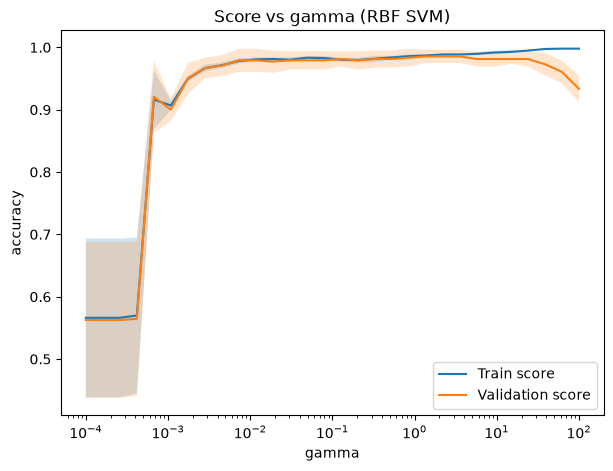

Mejor gamma según validación: 1.3738237958832638


In [6]:
plt.figure(figsize=(7, 5))
plt.semilogx(gammas, train_mean, label="Train score")
plt.fill_between(gammas, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.semilogx(gammas, val_mean, label="Validation score")
plt.fill_between(gammas, val_mean - val_std, val_mean + val_std, alpha=0.2)
plt.xlabel("gamma"); plt.ylabel("accuracy")
plt.legend(); plt.title("Score vs gamma (RBF SVM)")
plt.show()

best_gamma = gammas[np.argmax(val_mean)]
print("Mejor gamma según validación:", best_gamma)


## Análisis de la curva de validación en función de gamma

La curva obtenida permite analizar cómo cambia la capacidad de generalización del clasificador SVM con kernel RBF al modificar el hiperparámetro `gamma`.

El valor seleccionado mediante validación cruzada es

$$
\gamma_{\mathrm{óptimo}} \approx 1.374.
$$

Este valor corresponde al máximo del `validation score` dentro de la rejilla de valores de `gamma` explorada. Por tanto, la selección del hiperparámetro se realiza utilizando el desempeño de validación y no el desempeño sobre los datos de entrenamiento.

Para valores pequeños de `gamma`, el kernel RBF genera fronteras de decisión más suaves y de menor complejidad. Si `gamma` es demasiado pequeño, el modelo puede no tener suficiente flexibilidad para representar adecuadamente la estructura de los datos, produciendo un comportamiento asociado con *underfitting*.

Al aumentar `gamma`, aumenta la capacidad del modelo para responder a estructuras locales de los datos. En una región intermedia se alcanza el mejor desempeño de validación, lo que indica un compromiso favorable entre capacidad de ajuste y generalización.

Para valores suficientemente grandes de `gamma`, la frontera de decisión puede hacerse excesivamente local y compleja. En esta región, el score de entrenamiento puede continuar aumentando mientras el score de validación disminuye, lo que constituye una señal de *overfitting*.

Por tanto, el resultado muestra que aumentar la complejidad del modelo no garantiza una mejor generalización. El objetivo de la selección de hiperparámetros es encontrar una región en la que el modelo sea suficientemente flexible para capturar la estructura relevante de los datos, pero no tan flexible como para ajustarse a particularidades de la muestra de entrenamiento.

Las bandas alrededor de las curvas representan la dispersión del score entre los diferentes folds de la validación cruzada. Por ello, además del valor medio, resulta importante observar la estabilidad del desempeño: una configuración con score alto y menor variabilidad puede ser preferible a otra cuyo promedio sea similar pero presente mayor dispersión.


 ## Actividad 2a — Curva de aprendizaje con el mejor gamma

 Pregunta distinta a la anterior: con gamma fijo, ¿qué pasa al variarla cantidad de datos de entrenamiento?

 - Ambas curvas convergen alto → buen modelo.

 - Brecha grande y persistente → varianza alta (overfitting).

 - Ambas bajas → sesgo alto (underfitting); más datos no lo resuelven solos.

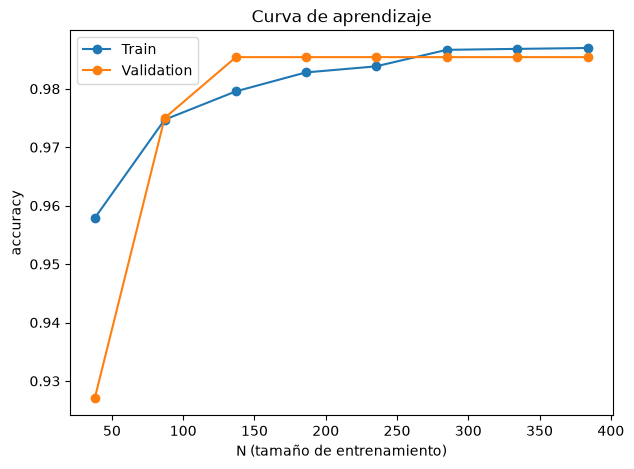

In [7]:
pipe_best = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", gamma=best_gamma))
])

train_sizes, train_scores_lc, val_scores_lc = learning_curve(
    pipe_best, X_trainval, y_trainval,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=cv, scoring="accuracy", n_jobs=-1
)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_scores_lc.mean(axis=1), "o-", label="Train")
plt.plot(train_sizes, val_scores_lc.mean(axis=1), "o-", label="Validation")
plt.xlabel("N (tamaño de entrenamiento)"); plt.ylabel("accuracy")
plt.legend(); plt.title("Curva de aprendizaje")
plt.show()


## Análisis de la curva de aprendizaje

La curva de aprendizaje permite estudiar cómo cambia el desempeño del modelo cuando se incrementa progresivamente la cantidad de datos utilizada para el entrenamiento, manteniendo fijo el valor de `gamma` seleccionado previamente.

En este caso se comparan dos cantidades:

* el `train score`, que mide el desempeño sobre los datos utilizados para ajustar el modelo;
* el `validation score`, que mide su capacidad de generalización mediante validación cruzada.

La diferencia entre ambas curvas permite diagnosticar el comportamiento del modelo.

Si el `train score` permanece considerablemente por encima del `validation score`, existe una brecha de generalización asociada con una posible varianza elevada y, por tanto, con *overfitting*. Si, por el contrario, ambos scores son bajos y relativamente cercanos, el modelo presenta una capacidad insuficiente para representar la estructura de los datos, lo que corresponde a *underfitting*.

Cuando ambas curvas se aproximan a valores altos al aumentar el número de ejemplos, se obtiene evidencia de una buena capacidad de generalización.

Además, la tendencia de las curvas permite analizar si aumentar la cantidad de datos podría mejorar el modelo. Si la brecha entre entrenamiento y validación disminuye al incorporar más ejemplos, una mayor cantidad de datos puede contribuir a reducir la varianza. Si ambas curvas convergen hacia valores bajos, aumentar los datos por sí solo probablemente no resolverá el problema y sería necesario modificar la complejidad o estructura del modelo.

Por tanto, la curva de aprendizaje complementa el análisis realizado mediante `gamma`: mientras la curva anterior estudia el efecto de modificar un hiperparámetro, esta gráfica estudia la dependencia del desempeño respecto de la cantidad de información disponible para entrenar.


 ## Actividad 2b — Verificación con GridSearchCV

In [14]:
param_grid = {"svc__gamma": gammas}
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring="accuracy", n_jobs=-1) #buscando theta con mejor score de validación cruzada
grid.fit(X_trainval, y_trainval)

print("Gamma óptimo (manual):      ", best_gamma)
print("Gamma óptimo (GridSearchCV):", grid.best_params_["svc__gamma"])
print("Score CV (GridSearchCV):    ", grid.best_score_)


Gamma óptimo (manual):       1.3738237958832638
Gamma óptimo (GridSearchCV): 1.3738237958832638
Score CV (GridSearchCV):     0.9854166666666668


## Comparación entre la selección manual y GridSearchCV

La selección manual del hiperparámetro y la realizada mediante `GridSearchCV` producen exactamente el mismo resultado:

$$
\gamma_{\mathrm{manual}}
=
\gamma_{\mathrm{GridSearchCV}}
\approx 1.374.
$$

Además, `GridSearchCV` obtiene un score medio de validación cruzada de

$$
S_{CV}\approx 0.9854.
$$

La coincidencia del valor óptimo confirma que el procedimiento manual implementado anteriormente reproduce correctamente el criterio de selección utilizado por `GridSearchCV`: evaluar las diferentes configuraciones de `gamma` mediante la misma estrategia de validación cruzada y seleccionar aquella que maximiza el score medio.

Esta coincidencia también permite verificar que la elección de `gamma` no depende de una inspección arbitraria de la gráfica, sino que corresponde al máximo obtenido mediante un criterio cuantitativo.

Por tanto, `GridSearchCV` no está produciendo una solución conceptualmente diferente a la obtenida manualmente, sino automatizando el proceso de exploración de la rejilla de hiperparámetros y comparación de sus respectivos desempeños.

La similitud entre ambos resultados constituye la verificación solicitada en la actividad 2.


 ## Paso 8 — Evaluación final en test (una sola vez)
 
 `X_test` nunca participó en decidir gamma, así que este score es una estimación honesta de generalización. No debe volver a usarse para ajustar el modelo después de verlo.

In [9]:
final_model = grid.best_estimator_
test_score = final_model.score(X_test, y_test)
print("Score final en test (única evaluación):", test_score)


Score final en test (única evaluación): 0.9666666666666667


## Análisis del desempeño final del modelo

Una vez seleccionado el hiperparámetro óptimo mediante validación cruzada, el modelo final se evalúa sobre el conjunto de test, que permaneció separado durante todo el proceso de selección.

El desempeño medio obtenido mediante validación cruzada fue

$$
S_{CV}\approx0.9854,
$$

mientras que el desempeño sobre el conjunto de test fue

$$
S_{\mathrm{test}}\approx0.9667.
$$

El score de test es ligeramente inferior al score medio de validación. Esta diferencia es esperable, ya que el conjunto de test constituye una muestra independiente que no participó en la selección del hiperparámetro.

La diferencia

$$
S_{CV}-S_{\mathrm{test}}\approx0.0187
$$

no representa por sí sola evidencia suficiente de un problema de sobreajuste. La validación cruzada y el conjunto de test corresponden a muestras diferentes y, por tanto, sus estimaciones de desempeño no tienen por qué coincidir exactamente.

En este caso, el desempeño de test permanece elevado y relativamente cercano al obtenido durante la validación, lo que proporciona evidencia de que el modelo seleccionado presenta una buena capacidad de generalización para este conjunto de datos.

Por tanto, el criterio final para considerar adecuado el modelo no es que maximice el score de entrenamiento, sino que mantenga un desempeño elevado cuando se enfrenta a datos que no participaron en su ajuste ni en la selección de sus hiperparámetros.


 ## Actividad 3 — Datasets artificiales para overfitting y underfitting
 Se construyen nubes gaussianas manipulando mu (centro) y Sigma (forma,orientación, correlación) para forzar cada patrón.

In [10]:
def gen_gaussian_data(mu0, mu1, cov0, cov1, n=300, seed=0):
    rng = np.random.default_rng(seed)
    X0 = rng.multivariate_normal(mu0, cov0, n)
    X1 = rng.multivariate_normal(mu1, cov1, n)
    X_gen = np.vstack([X0, X1])
    y_gen = np.array([0] * n + [1] * n)
    return X_gen, y_gen


def plot_boundary(model, X_plot, y_plot, title):
    xx, yy = np.meshgrid(
        np.linspace(X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1, 300),
        np.linspace(X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1, 300)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y_plot, edgecolor="k", cmap="coolwarm")
    plt.title(title)
    plt.show()


 ### Caso underfitting
 Medias cercanas + covarianzas grandes -> clases muy solapadas. gamma muy pequeño -> frontera casi lineal/suave, incapaz de separar incluso el propio conjunto de entrenamiento.

Score underfitting (train): 0.575


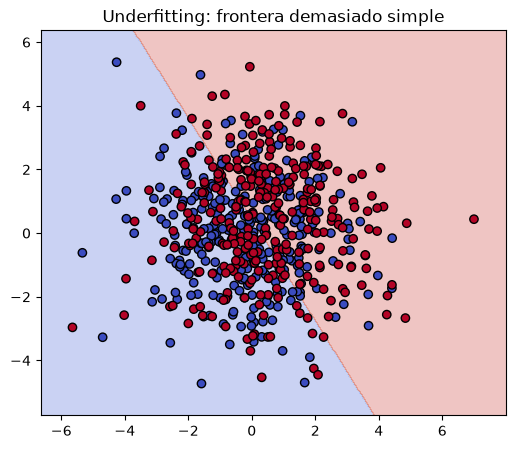

In [11]:
X_under, y_under = gen_gaussian_data(
    mu0=[0, 0], mu1=[0.5, 0.5],
    cov0=[[3, 0], [0, 3]], cov1=[[3, 0], [0, 3]],
    seed=1
)

model_under = SVC(kernel="rbf", gamma=1e-4)
model_under.fit(X_under, y_under)
print("Score underfitting (train):", model_under.score(X_under, y_under))

plot_boundary(model_under, X_under, y_under, "Underfitting: frontera demasiado simple")


### Análisis del caso de underfitting

En este caso se construyó un conjunto de datos en el que las medias de las dos clases se encuentran próximas,

$$
\mu_0=(0,0), \qquad \mu_1=(0.5,0.5),
$$

mientras que ambas clases presentan covarianzas relativamente grandes,

$$
\Sigma_0=\Sigma_1=
\begin{pmatrix}
3&0\\
0&3
\end{pmatrix}.
$$

La combinación de estos parámetros produce un fuerte solapamiento entre las distribuciones de las dos clases. Desde el punto de vista geométrico, las nubes de puntos ocupan regiones amplias que se superponen considerablemente, por lo que la separación entre las clases resulta difícil.

Además, se utiliza un valor muy pequeño de `gamma`,

$$
\gamma=10^{-4},
$$

lo que restringe considerablemente la variación espacial de la función de decisión del kernel RBF y produce una frontera de decisión suave.

El resultado obtenido muestra que el modelo presenta un desempeño limitado incluso sobre los datos utilizados durante el entrenamiento. Esto es una característica importante del *underfitting*: el problema no consiste principalmente en que el modelo memorice los datos y falle al generalizar, sino en que su capacidad de representación no es suficiente para obtener un buen ajuste.

Por tanto, en este caso el comportamiento observado se interpreta como una combinación de una distribución difícil de separar y una complejidad insuficiente del modelo. La modificación de `gamma` permite controlar la flexibilidad de la frontera, mientras que las medias y covarianzas determinan la dificultad geométrica inherente al conjunto de datos.


 ### Caso overfitting
 Medias bien separadas pero con pocos datos y gamma muy grande -> el modelo memoriza el ruido local en vez de la estructura general.

Score overfitting (train): 1.0


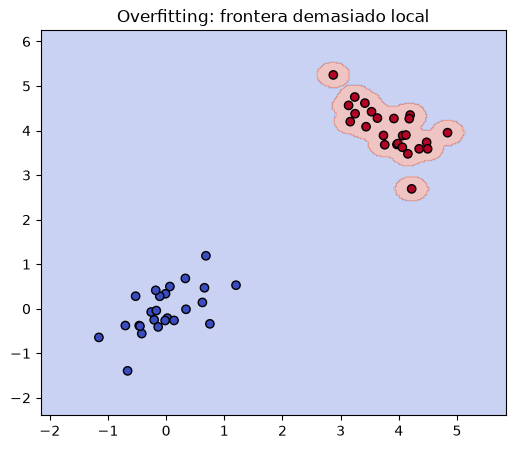

In [12]:
X_over, y_over = gen_gaussian_data(
    mu0=[0, 0], mu1=[4, 4],
    cov0=[[0.3, 0.2], [0.2, 0.3]], cov1=[[0.3, -0.2], [-0.2, 0.3]],
    n=25, seed=2
)

model_over = SVC(kernel="rbf", gamma=50)
model_over.fit(X_over, y_over)
print("Score overfitting (train):", model_over.score(X_over, y_over))

plot_boundary(model_over, X_over, y_over, "Overfitting: frontera demasiado local")


### Análisis del caso de overfitting

Para construir este caso se utilizaron medias bien separadas,

$$
\mu_0=(0,0), \qquad \mu_1=(4,4),
$$

junto con matrices de covarianza diferentes,

$$
\Sigma_0=
\begin{pmatrix}
0.3&0.2\\
0.2&0.3
\end{pmatrix},
\qquad
\Sigma_1=
\begin{pmatrix}
0.3&-0.2\\
-0.2&0.3
\end{pmatrix}.
$$

La separación entre las medias hace que las clases sean geométricamente distinguibles, mientras que las covarianzas introducen orientaciones diferentes en las nubes de puntos.

Para favorecer el sobreajuste se utiliza una muestra pequeña, con \(n=25\) observaciones por clase, y un valor elevado de `gamma`,

$$
\gamma=50.
$$

Un `gamma` elevado permite construir fronteras de decisión muy locales y flexibles. La combinación de una muestra pequeña y una elevada flexibilidad del modelo facilita que el clasificador se ajuste con mucha precisión a los ejemplos concretos utilizados durante el entrenamiento.

Sin embargo, el criterio decisivo para identificar el overfitting no es únicamente obtener un score alto en entrenamiento. Para comprobar la capacidad de generalización se genera posteriormente una nueva muestra, independiente de la primera, pero procedente de las mismas distribuciones estadísticas.

La comparación entre el desempeño sobre entrenamiento y el desempeño sobre esta nueva muestra permite determinar si la frontera aprendida generaliza o si se ajustó excesivamente a la muestra original.

Si se observa un score de entrenamiento muy superior al score obtenido sobre la nueva muestra, existe evidencia directa de una brecha de generalización asociada con alta varianza y, por tanto, con *overfitting*.

Este resultado muestra que un score de entrenamiento elevado no es suficiente para considerar que un modelo sea adecuado. Lo relevante es que el modelo conserve un desempeño elevado sobre datos que no utilizó durante el aprendizaje.



In [13]:
# Generamos nuevos datos de la MISMA distribución para medir generalización real
X_over_test, y_over_test = gen_gaussian_data(
    mu0=[0, 0], mu1=[4, 4],
    cov0=[[0.3, 0.2], [0.2, 0.3]], cov1=[[0.3, -0.2], [-0.2, 0.3]],
    n=200, seed=99
)
print("Score overfitting (test, misma distribución):", model_over.score(X_over_test, y_over_test))


Score overfitting (test, misma distribución): 0.8875


## Comparación del desempeño en entrenamiento y en datos nuevos

El experimento permite comparar directamente el desempeño del modelo sobre los datos utilizados para entrenarlo con el desempeño sobre una nueva muestra procedente de la misma distribución estadística.

El criterio relevante es la brecha

$$
\Delta S =
S_{\mathrm{train}}-S_{\mathrm{test}}.
$$

Un valor pequeño de \(\Delta S\) indicaría que el modelo mantiene un comportamiento similar al enfrentarse a datos nuevos. En cambio, una diferencia grande entre ambos scores constituye evidencia de que el modelo está capturando características específicas de la muestra de entrenamiento que no se mantienen en la nueva muestra.

En consecuencia, la comparación entre ambos scores permite distinguir un modelo que simplemente obtiene un buen ajuste de entrenamiento de uno que realmente presenta una buena capacidad de generalización.

Este experimento complementa el análisis realizado en las actividades anteriores: mientras la curva de validación mostró cómo `gamma` modifica la complejidad de la frontera y la curva de aprendizaje estudió el efecto de aumentar la cantidad de datos, este caso permite visualizar directamente las consecuencias de utilizar una frontera excesivamente flexible sobre una muestra pequeña.

Por tanto, el overfitting puede entenderse como un problema de desbalance entre la complejidad efectiva del modelo y la cantidad de información disponible para determinar esa complejidad.


## Discusión general

Los resultados obtenidos permiten interpretar el comportamiento del clasificador SVM con kernel RBF desde tres elementos que están directamente relacionados: la distribución de los datos, la complejidad del modelo y su capacidad de generalización.

En primer lugar, la variación de `gamma` mostró que la complejidad del modelo debe seleccionarse cuidadosamente. Un valor demasiado pequeño puede producir una frontera insuficientemente flexible y conducir a *underfitting*, mientras que valores excesivamente grandes pueden producir fronteras demasiado locales y favorecer el *overfitting*. El valor seleccionado mediante validación cruzada fue

$$
\gamma_{\mathrm{óptimo}}\approx1.374.
$$

La coincidencia entre este resultado y el obtenido mediante `GridSearchCV` confirma que el procedimiento manual de selección reproduce correctamente el criterio de búsqueda sistemática de hiperparámetros.

En segundo lugar, la evaluación final sobre el conjunto de test produjo un score de aproximadamente

$$
S_{\mathrm{test}}\approx0.967,
$$

mientras que el score medio de validación cruzada fue aproximadamente

$$
S_{CV}\approx0.985.
$$

El desempeño elevado sobre ambos conjuntos proporciona evidencia de una buena generalización para el dataset estudiado. La diferencia entre ambos valores no debe interpretarse por sí sola como sobreajuste, ya que corresponden a muestras diferentes.

En tercer lugar, las curvas de aprendizaje permiten analizar el comportamiento del modelo al aumentar la cantidad de datos. Estas curvas complementan el análisis de `gamma`, ya que permiten distinguir si las limitaciones observadas están relacionadas principalmente con la cantidad de datos disponible o con la capacidad del modelo.

Finalmente, la construcción de datasets artificiales muestra que el desempeño de un clasificador no depende exclusivamente del algoritmo utilizado. Las medias y matrices de covarianza determinan la posición, dispersión, orientación y grado de solapamiento de las clases. Estas propiedades modifican la dificultad geométrica del problema y, por consiguiente, la complejidad de la frontera de decisión necesaria para obtener una buena clasificación.

En conjunto, los resultados permiten establecer que un modelo adecuado no es aquel que simplemente maximiza su desempeño sobre los datos de entrenamiento. El criterio fundamental es alcanzar un equilibrio entre capacidad de ajuste y capacidad de generalización:

$$
\boxed{
\text{Buen modelo}
\;\Longrightarrow\;
\text{buen ajuste}+\text{buena generalización}
}
$$

Por tanto, la selección de hiperparámetros, la validación cruzada, las curvas de aprendizaje y la evaluación sobre datos independientes constituyen herramientas complementarias para determinar si el modelo aprendido representa una estructura estadística general de los datos o simplemente particularidades de la muestra utilizada durante el entrenamiento.
